# Côa Valley Eco-Connectivity v3: Land, Water, Air, Fire, Strategic Expansion

**Rewilding Portugal / Solo Field Illustrator project — scientific track**

v3 adds one thing on top of v2 (fire barrier + catchment-extended study area, both unchanged below): a comparison against savanna-landscape rewilding, land restoration, and ecotourism initiatives in Limpopo province, South Africa — grounded in real South African government/policy/academic sources, aimed specifically at **supporting the strategic expansion of the Greater Côa Valley initiative**, not description for its own sake. Every comparison point in that new section (near the end, before Handoff) ends in a concrete "what this could mean for expanding Rewilding Portugal's own work" implication.

v1 and v2 are both kept intact alongside this notebook. Same multi-species framework throughout — Prima et al. (2024), *Methods in Ecology and Evolution* 15:2385–2399 — same land/water/air movement-medium framing, same script-per-step structure in `scripts/`.

In [1]:
import os
os.chdir("../scripts")

from IPython.display import Image, display
import sys
sys.path.insert(0, "..")
import config

## Framing: safe and just

Unchanged from v1 — carried forward, not re-derived:

- **Safe** — sensitive-species locations (currently the European wildcat, *Felis silvestris*) are never mapped at exact coordinates; `acquire_field_observations.py` generalises any record mentioning a sensitive species to a 5km grid cell before it reaches any figure, map, or export, per the open data-handling item in `survey123/memo-data-use.md`.
- **Just** — eco-tourism recommendations are checked against the combined connectivity output and against multi-site reachability, not folded silently into siting decisions. Land-tenure context (private reserves, hunting zones) stays descriptive, not a modelled barrier/asset — this project has no first-hand knowledge of any specific estate's management.

## Study area and data provenance (v2: catchment-extended)

v1's study area was a flat 30km buffer around the OSM-derived Côa river centerline — 9,377 km². v2 adds a second component: the Côa's own tributary network, traced from the national HydroRIVERS dataset (`data-management/data/raw/colab/hydrorivers_100.gpkg`) via its `NEXT_DOWN` topology, so headwater tributaries running beyond the mainstem band are captured too. Traced this way: the Côa's own mouth reach (found by snapping the OSM line onto HydroRIVERS and picking the plausible match — see `acquire_study_area.py`'s docstring for why a plain "highest upstream area" pick would jump onto the Douro instead) came out at **2,512.6 km² upstream area, matching the Côa's published ~2,495 km² drainage basin almost exactly** — a good sign the trace found the right reach. The full traced network is 39 reaches, 251.9 km total length.

Buffering that traced network and unioning with the original mainstem buffer grows the study area from **9,377 km² to 10,230 km² (+9.1%)** — a real but modest extension, not a dramatic one, since this HydroRIVERS product's generalised tributary network doesn't run much wider than the mainstem's own footprint for this particular basin. Stated plainly rather than oversold.

**Rewilding Portugal's own Greater Côa Valley project boundary** (318,000 ha / 3,180 km², per the annual review and the Endangered Landscapes & Seascapes Programme project page — "between the Malcata mountains and the Douro Valley") has no boundary polygon anywhere in either repo, only that prose figure. The catchment-extended study area is already **3.2x larger by area** and spans a comparable north-south range, so it's kept as the working study area rather than fabricating a precise 318,000ha boundary from prose description alone.

All raster work runs in EPSG:3035 (matching the sibling `data-management` repo's national base layers, still 100m resolution); field and GBIF data are handled in EPSG:4326 until reprojected.

*Added in v3*: this "safe and just" framing echoes Kate Raworth's "safe and just space for humanity" model (the "doughnut economics" framework) — worth naming explicitly now that this project has a directly relevant precedent: Cole, Bailey & New (2017) applied that same framework at **provincial level across all nine South African provinces, including Limpopo** ("Spatial variability in sustainable development trajectories in South Africa: provincial level safe and just operating spaces," *Sustainability Science*, https://link.springer.com/article/10.1007/s11625-016-0418-9). See the new Limpopo section near the end of this notebook for the full comparison.

In [2]:
%run acquire_study_area.py
%run acquire_field_observations.py
%run acquire_environmental_covariates.py

Tracing Côa catchment from HydroRIVERS...
  884 HydroRIVERS reaches in the regional bbox (-8.3, 39.6, -6.0, 41.6)
  Côa mouth reach: HYRIV_ID=20590885, UPLAND_SKM=2512.6 (published Côa basin area: ~2,495 km2), 30 reaches snapped to the OSM line total
  Traced catchment: 39 reaches, 251.9 km total

Study area (v2, catchment-extended):
  Mainstem-only buffer (v1 equivalent): 9,377 km2
  With traced tributary catchment:      10,230 km2 (+9.1%)
  Rewilding Portugal's own Greater Côa Valley project area (prose figure, no boundary polygon exists): 3,180 km2
  -> the river-buffer study area is 3.2x larger by area and spans a comparable north-south range;
     kept as-is rather than fabricating a precise 318,000ha boundary from prose (see module docstring).
Extent (EPSG:4326): [-7.59022031 40.00217558 -6.53775962 41.35292564]
Wrote /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/data/processed/study_area.gpkg
12 field visits loaded, 

Clipping rasters...
  elevation: (1, 1517, 862) -> /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/data/processed/covariates/elevation.tif
  slope_degrees: (1, 1517, 862) -> /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/data/processed/covariates/slope_degrees.tif


  ruggedness_tri: (1, 1517, 862) -> /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/data/processed/covariates/ruggedness_tri.tif
  hillshade: (1, 1517, 862) -> /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/data/processed/covariates/hillshade.tif
  road_raster: (1, 1517, 862) -> /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/data/processed/covariates/road_raster.tif
  motorway_raster: (1, 1517, 862) -> /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/data/processed/covariates/motorway_raster.tif


  distance_to_road_m: (1, 1517, 862) -> /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/data/processed/covariates/distance_to_road_m.tif
  landcover_clcplus: (1, 1517, 862) -> /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/data/processed/covariates/landcover_clcplus.tif
  imperviousness: (1, 1517, 862) -> /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/data/processed/covariates/imperviousness.tif
Clipping vectors...
  Reading Natura 2000 (bbox-filtered, source is large)...


  natura2000: 27 features
  water_bodies: 973 features


  wrote 01_study_area.png


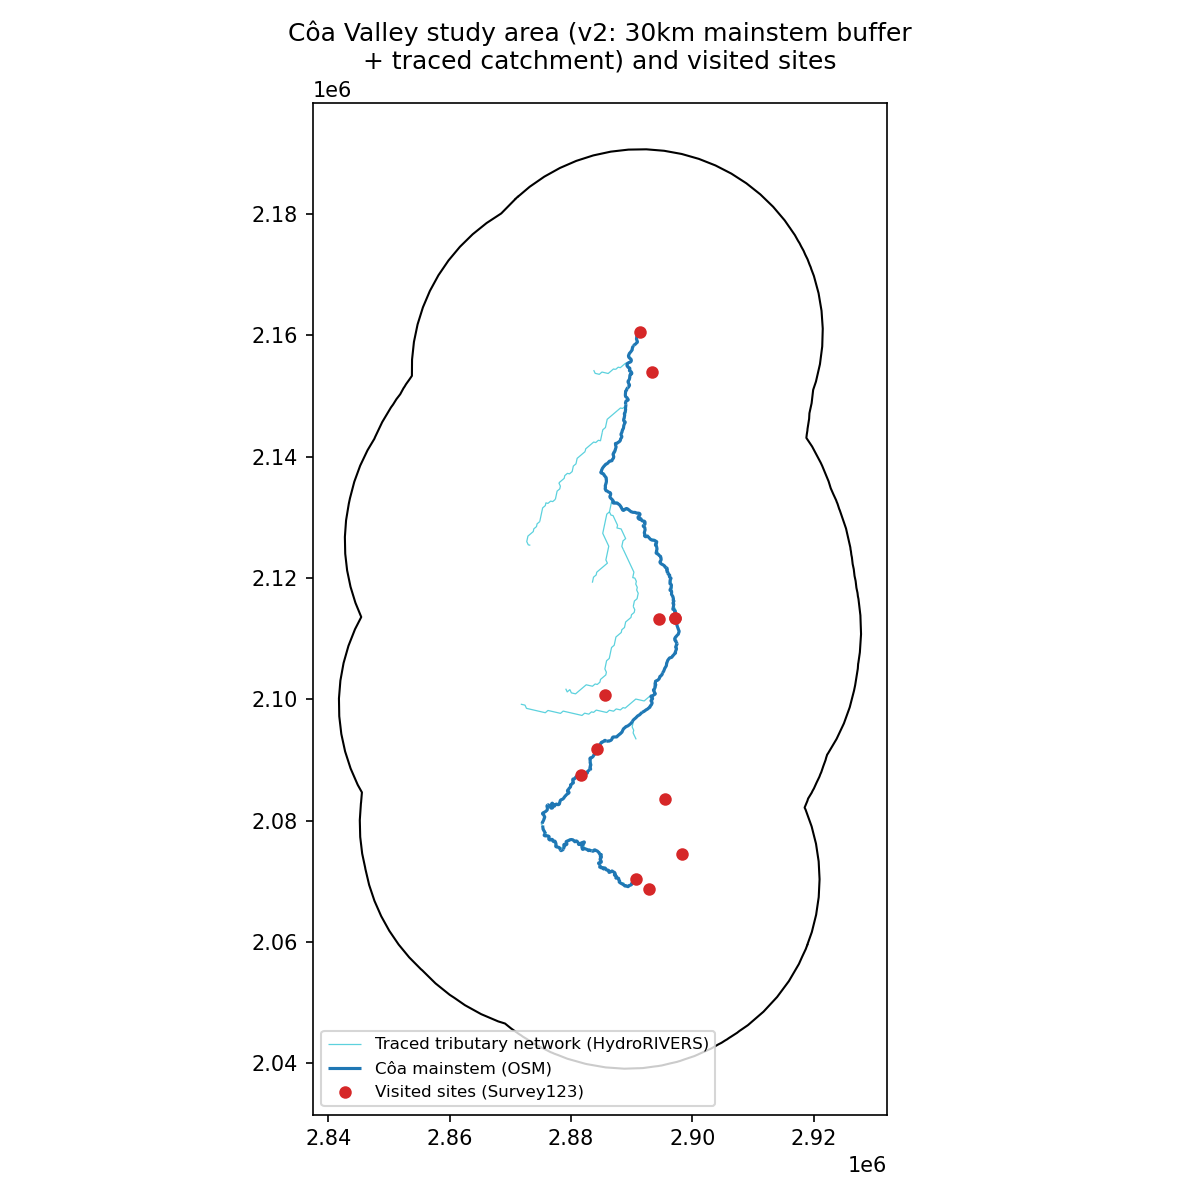

In [3]:
import generate_maps
generate_maps.OUT_DIR.mkdir(parents=True, exist_ok=True)
generate_maps.map_01_study_area()
display(Image(str(config.OUTPUT_MAPS / "01_study_area.png")))

## Method

Unchanged core framework from v1 — Prima et al. (2024)'s four steps (functional grouping → suitability/resistance → circuit theory → protected-area overlay), reframed around movement medium (land/water/air), with the same two stated simplifications (one RF model per group instead of a four-algorithm ensemble; one resistance-shape/search-radius parameter set instead of Prima's uncertainty sweep).

**v2 addition to the resistance step**: after the existing suitability→resistance transform (Prima's Eq. 1, single *c*=4 per group), the **Land** group gets an additional fire-barrier penalty — see the dedicated Fire section below, after the three group plates, for the full data-provenance story and results. Water and Air resistance are untouched by this addition.

Circuit theory is still pure Python (`scripts/run_omniscape.py`, `scipy.sparse` moving-window solver), not Julia Omniscape.jl or the broken legacy `circuitscape` PyPI package.

### Species occurrence data (GBIF)

Same nine focal species, same cached GBIF downloads, same permissive 30km coordinate-uncertainty threshold (Prima et al.'s own <1km filter would discard almost all of this project's carnivore data — one wolf record here is offset ~28km from its true location, a deliberate generalisation to protect the species). The larger v2 study area pulls in slightly more data for every group: **land 38→42 usable points**, water 362 (up from a smaller v1 figure), air 8,600. Still thin for the Land group in absolute terms — carried forward honestly, not smoothed over.

In [4]:
%run acquire_gbif_occurrences.py

  Canis lupus (Canis_lupus): 138 raw -> 137 usable
  Felis silvestris (Felis_silvestris): 7 raw -> 7 usable
  Cervus elaphus (Cervus_elaphus): 733 raw -> 733 usable
Land: 877 total, 42 within 30.0km study area
  Lutra lutra (Lutra_lutra): 1704 raw -> 1701 usable
  Pseudochondrostoma polylepis (P_polylepis): 38 raw -> 38 usable
  Squalius alburnoides (Squalius_alburnoides): 568 raw -> 568 usable
  Emys orbicularis (Emys_orbicularis): 319 raw -> 319 usable
Water: 2626 total, 362 within 30.0km study area


  Gyps fulvus (Gyps_fulvus): 32927 raw -> 32897 usable
  Neophron percnopterus (N_percnopterus): 7139 raw -> 7139 usable
  Aquila chrysaetos (Aquila_chrysaetos): 4139 raw -> 4139 usable
Air: 44175 total, 8600 within 30.0km study area
Wrote /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/data/processed/gbif_occurrences.gpkg


### Suitability models and resistance surfaces

Same covariate stacks as v1 (land/water: elevation, slope, ruggedness, landcover, distance-to-road, imperviousness; air: topography only). Real accuracies from this run — land 0.99, water 0.96, air 0.79 — close to v1's 0.80–0.99 range, small residual differences reflect the extended extent's background sample plus `RandomForestClassifier`'s own inherent randomness (no fixed `random_state` at this scoping level).

In [5]:
%run build_suitability_models.py
%run build_resistance_surfaces.py

  land: n_presence=42, n_background=2000, train accuracy=0.99


  wrote /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/data/processed/suitability/land_suitability.tif


  water: n_presence=2828, n_background=2000, train accuracy=0.96


  wrote /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/data/processed/suitability/water_suitability.tif


  air: n_presence=68044, n_background=2000, train accuracy=0.78


  wrote /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/data/processed/suitability/air_suitability.tif
  Fire penalty applied to 131618 cells (10.07% of grid), penalty range [10, 60]
Land: c=4.0, resistance range [2.2, 100.0], mean 87.7
  wrote /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/data/processed/resistance/land_resistance.tif
Water: c=4.0, resistance range [1.0, 93.6], mean 70.7
  wrote /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/data/processed/resistance/water_resistance.tif


Air: c=4.0, resistance range [1.0, 74.2], mean 26.5
  wrote /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/data/processed/resistance/air_resistance.tif


The printed training accuracies above are **not a validation metric** — same caveat as v1, unchanged: fit on the same points used to train, no held-out split, no movement-tracking data to check against (Prima et al. themselves flag this as a field-wide gap, p.2396). The air group's high suitability almost everywhere still most likely reflects citizen-science recording density, not true habitat preference.

### Circuit theory (pure Python)

Runtime note, updated for v2's larger grid: the three group solves (now against a 10,230km² extent instead of 9,377km²) still complete in well under a minute on a laptop — the moving-window solver's cost scales with dispersal-radius-in-pixels x grid size, not a hardcoded extent, so the 9% area growth from catchment tracing didn't meaningfully change runtime.

In [6]:
%run run_omniscape.py

Land (dispersal 80.0km):
    209 windows (radius=80px, block=8px, grid 152x87)


    209 windows (radius=80px, block=8px, grid 152x87)


  normalized_current range [0.738, 1.892], mean 0.998
  wrote land_{current_flow,flow_potential,normalized_current}.tif
Water (dispersal 20.0km):
    3344 windows (radius=20px, block=2px, grid 152x87)


    3344 windows (radius=20px, block=2px, grid 152x87)


  normalized_current range [0.561, 4.497], mean 0.983
  wrote water_{current_flow,flow_potential,normalized_current}.tif
Air (dispersal 100.0km):
    144 windows (radius=100px, block=10px, grid 152x87)


    144 windows (radius=100px, block=10px, grid 152x87)


  normalized_current range [0.238, 4.394], mean 1.042
  wrote air_{current_flow,flow_potential,normalized_current}.tif


### Land — wolf, wildcat, red deer (now fire-aware)

Same species and ground-truth as v1 (free-ranging cattle and a possible Sorraia-phenotype horse herd near Almeida/Lageosa, Survey123, flagged unconfirmed). New in v2: this group's resistance surface now includes the fire-barrier penalty (see the Fire section below) — the map here already reflects that, not a separate "before" version (that comparison lives in its own map, further down).

  wrote 03_land_connectivity.png


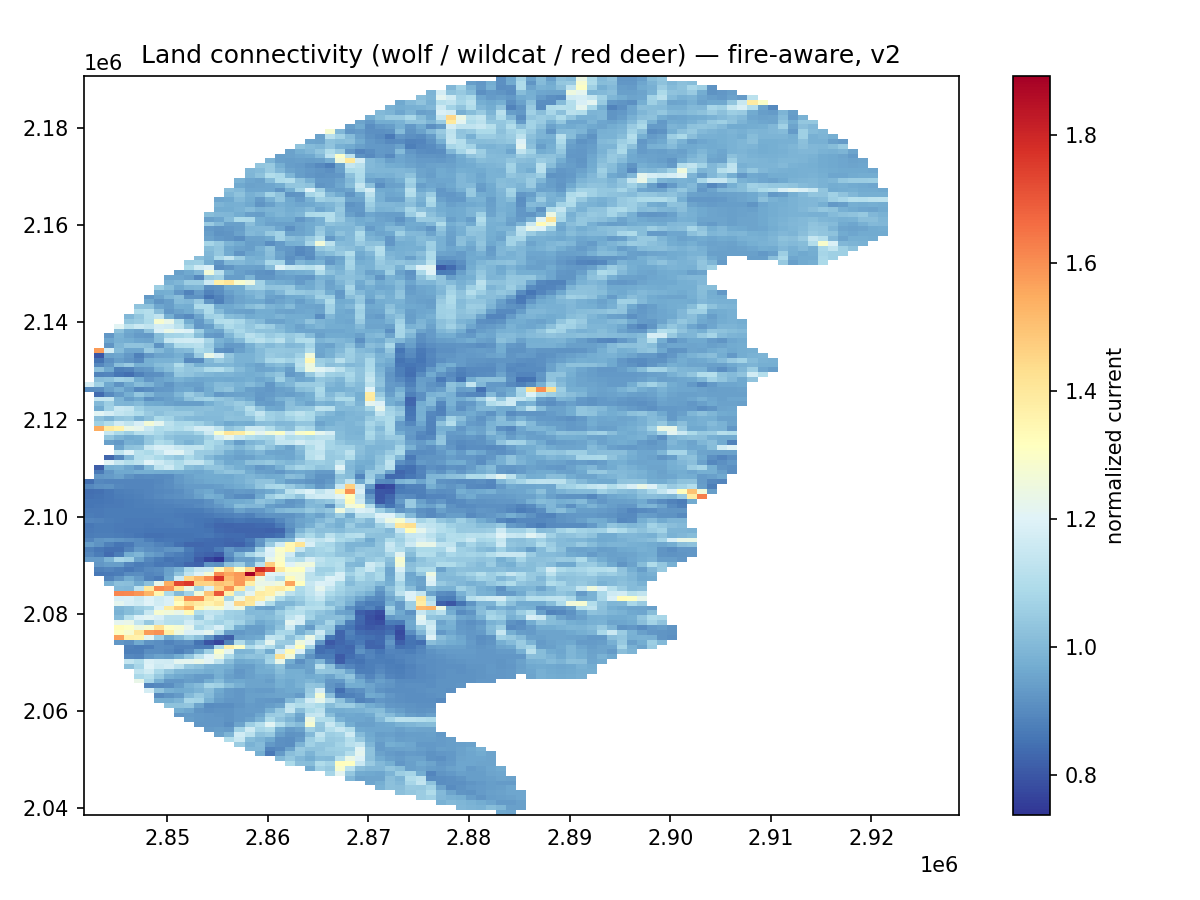

In [7]:
generate_maps._plot_raster(config.OUTPUT_RASTERS / "land_normalized_current.tif",
                            "Land connectivity (wolf / wildcat / red deer) — fire-aware, v2", "RdYlBu_r",
                            out_name="03_land_connectivity.png", cbar_label="normalized current")
display(Image(str(config.OUTPUT_MAPS / "03_land_connectivity.png")))

### Water — otter, native fish, pond turtle (catchment-aware extent)

Same species and barrier cases as v1 (Pontão Manuel José weir; the Foz Côa cofferdam, still periodically flooding 119 rock-art panels). What changed in v2 isn't the resistance logic itself — still topography/landcover/imperviousness/roads, no direct hydrology covariate, same as v1 — but the **extent** it now runs over: the traced tributary network (39 reaches, 251.9km, map above) means this group's suitability/resistance/circuit solve now covers real Côa tributary catchment beyond the old 30km mainstem band, not just a hard clip at that band's edge. Post-fire erosion/sediment effects on water connectivity are a real, un-modelled interaction — noted as an open item, not implemented, to keep this addition contained to the land group as asked.

  wrote 04_water_connectivity.png


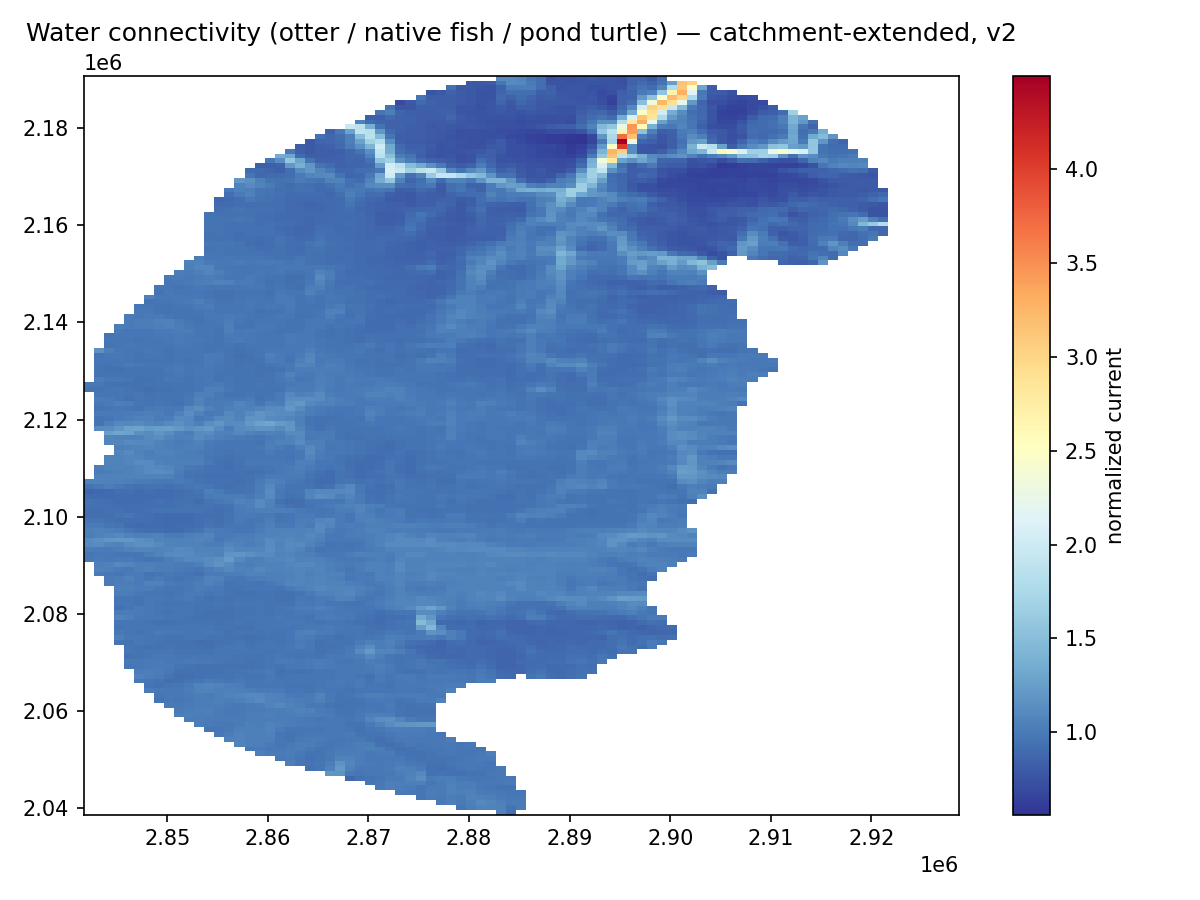

In [8]:
generate_maps._plot_raster(config.OUTPUT_RASTERS / "water_normalized_current.tif",
                            "Water connectivity (otter / native fish / pond turtle) — catchment-extended, v2", "RdYlBu_r",
                            out_name="04_water_connectivity.png", cbar_label="normalized current")
display(Image(str(config.OUTPUT_MAPS / "04_water_connectivity.png")))

### Air — griffon vulture, Egyptian vulture, golden eagle

Unchanged from v1 — topography-driven resistance logic (no roads/fire), same raptor guild expected over the Douro Superior / Côa gorge, still no confirmed field sighting for this group.

  wrote 05_air_connectivity.png


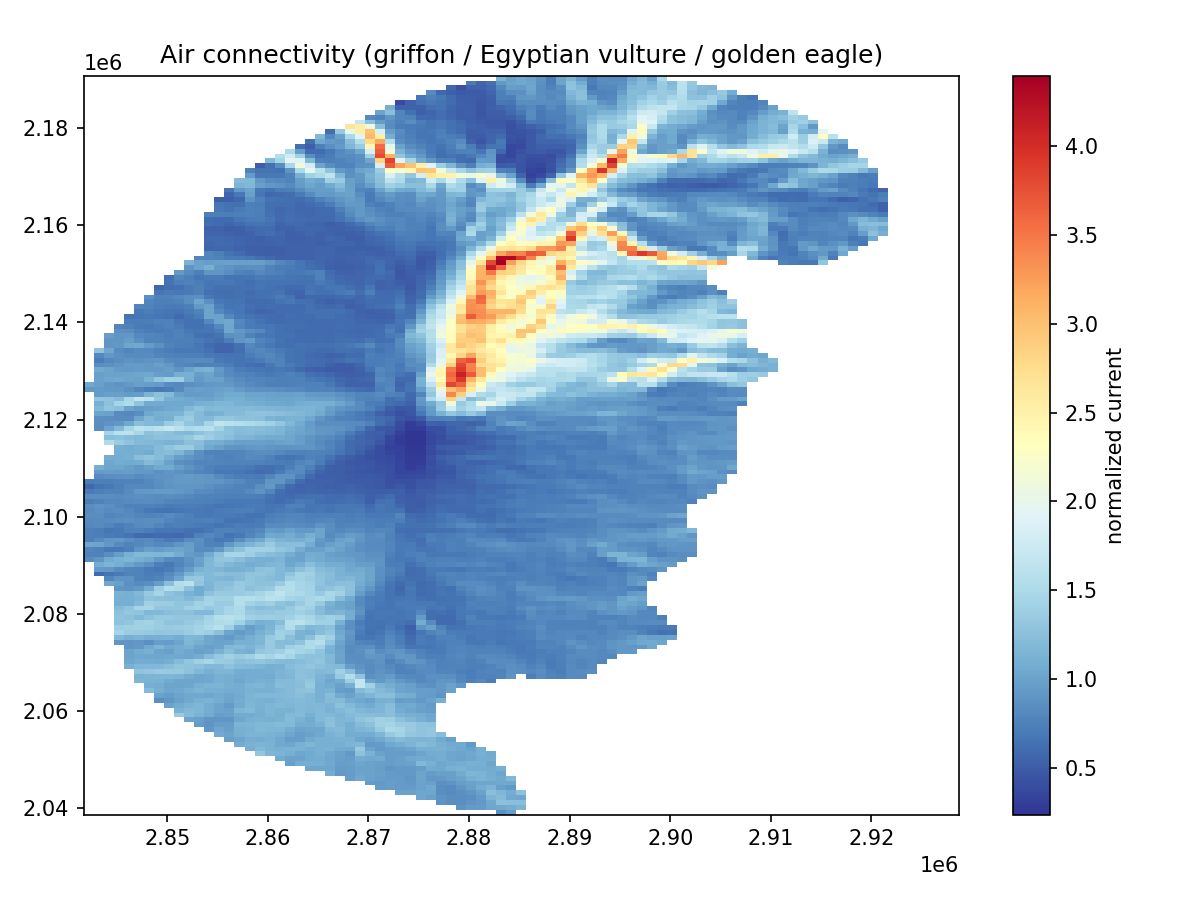

In [9]:
generate_maps._plot_raster(config.OUTPUT_RASTERS / "air_normalized_current.tif",
                            "Air connectivity (griffon / Egyptian vulture / golden eagle)", "RdYlBu_r",
                            out_name="05_air_connectivity.png", cbar_label="normalized current")
display(Image(str(config.OUTPUT_MAPS / "05_air_connectivity.png")))

## Fire as a barrier to land restoration (new in v2)

Rewilding Portugal's 2025 annual review (`RW_01_AnnualReview2025_ENGLISH_FINALWEB.pdf`) documents wildfires burning roughly 10% of the 318,000ha Greater Côa Valley in 2025, hitting the Ermo das Águias rewilding area hardest (a quarter of its area affected, per the review's own "Iberian Peninsula on fire" section), and names "Fire Risk" as one of the project's own monitoring indicators. That's the motivation for this section — but the review itself has no fire-perimeter geometry, only narrative description, so it's cited here as context, not as the data source.

**Data source, and a real dead end worth stating rather than hiding**: EFFIS (European Forest Fire Information System, JRC) was the first choice for real historical burnt-area perimeters. Two things blocked it, checked directly this session: its actual historical GIS archive requires a manual data-request form (`https://effis.jrc.ec.europa.eu/apps/data.request.form`), not an open API; and its live WFS burnt-area layer (`ercc.ba`) returned a server-side error (`msOracleSpatialLayerOpen(): ... Connection failure`) when queried. Confirmed with Linda: used **NASA's MODIS Burned Area Monthly product (MCD64A1.061)** instead — real satellite-derived burn history, served as public, no-auth Cloud-Optimized GeoTIFFs via Microsoft Planetary Computer's STAC API. Same spirit (real observed fire history, not a synthetic flammability proxy), different real source.

**A second data-currency limitation, also worth stating plainly**: Planetary Computer's ingestion of this MODIS product currently tops out at day 182 of 2025 (~1 July 2025) — checked globally, not just for this tile. That means it **cannot** capture the annual review's own 2025 summer fires (if they landed after that date, which the review's "this summer" framing suggests) or the field-note-documented wildfire near Almeida/Sabugal/Pinhel from 27–29 July 2026 (`field-trips/2026-08-16-Wildfire-Damage-Amoreira-Castelo-Mendo.md`). Both stay narrative-only here — the fire layer below is real data, just not current through today.

**What the real data shows** (2015 – 1 July 2025, 124 monthly MODIS items covering this tile): **10.07% of the extended study area's grid cells show at least one detected burn** in this ~10-year window. The largest single-month burn events fall in 2015, 2017, and 2022 — all independently known as severe Portugal wildfire seasons nationally, which is a reasonable real-world sanity check that this dataset is picking up genuine signal, not noise.

In [10]:
%run acquire_fire_history.py

Fire history: 124 monthly MODIS items found for 2015-01-01 onward


  MCD64A1.A2015060.h17v04.061.2021323224816: 109 burned px (year 2015)


  MCD64A1.A2015152.h17v04.061.2021329112444: 42 burned px (year 2015)


  MCD64A1.A2015182.h17v04.061.2021331180238: 2001 burned px (year 2015)


  MCD64A1.A2015213.h17v04.061.2021333043838: 15767 burned px (year 2015)


...

  MCD64A1.A2023152.h17v04.061.2023221044604: 44 burned px (year 2023)


  MCD64A1.A2023213.h17v04.061.2023284052200: 1333 burned px (year 2023)


  MCD64A1.A2024245.h17v04.061.2024317180214: 129 burned px (year 2024)


  MCD64A1.A2025152.h17v04.061.2025220180150: 87 burned px (year 2025)


  MCD64A1.A2025182.h17v04.061.2025258122820: 2391 burned px (year 2025)
  Last item processed: A2025182 (this is the true data-currency cutoff, not config.FIRE_HISTORY_END)
Total pixels with a recorded burn in the window: 131618 (10.07% of the study area grid)
Wrote /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/data/processed/covariates/fire_last_burn_year.tif


**Folding into land resistance**: burned cells get a penalty added on top of the existing suitability-derived resistance, scaled by how recently they burned (10 points for a burn at the start of the 2015 window, up to 60 points for the most recent 2025 burns), capped at the same 100-point ceiling the rest of the resistance surface already uses. Real effect size, not oversold: **131,618 cells penalised (10.07% of the grid)**, and the Land group's mean resistance moves from **86.98 → 87.74** — a modest, real shift, not a dramatic one, since most heavily-burned cells were already moderately-to-highly resistant from the suitability model alone (the RF model's land-cover/ruggedness features already respond to some of the same landscape conditions that drive fire).

Land-group-only, per the ask — Water and Air resistance are untouched by fire in this pass (the post-fire erosion/sediment question on the water side is a real, un-modelled interaction, listed in Limitations below rather than implemented here).

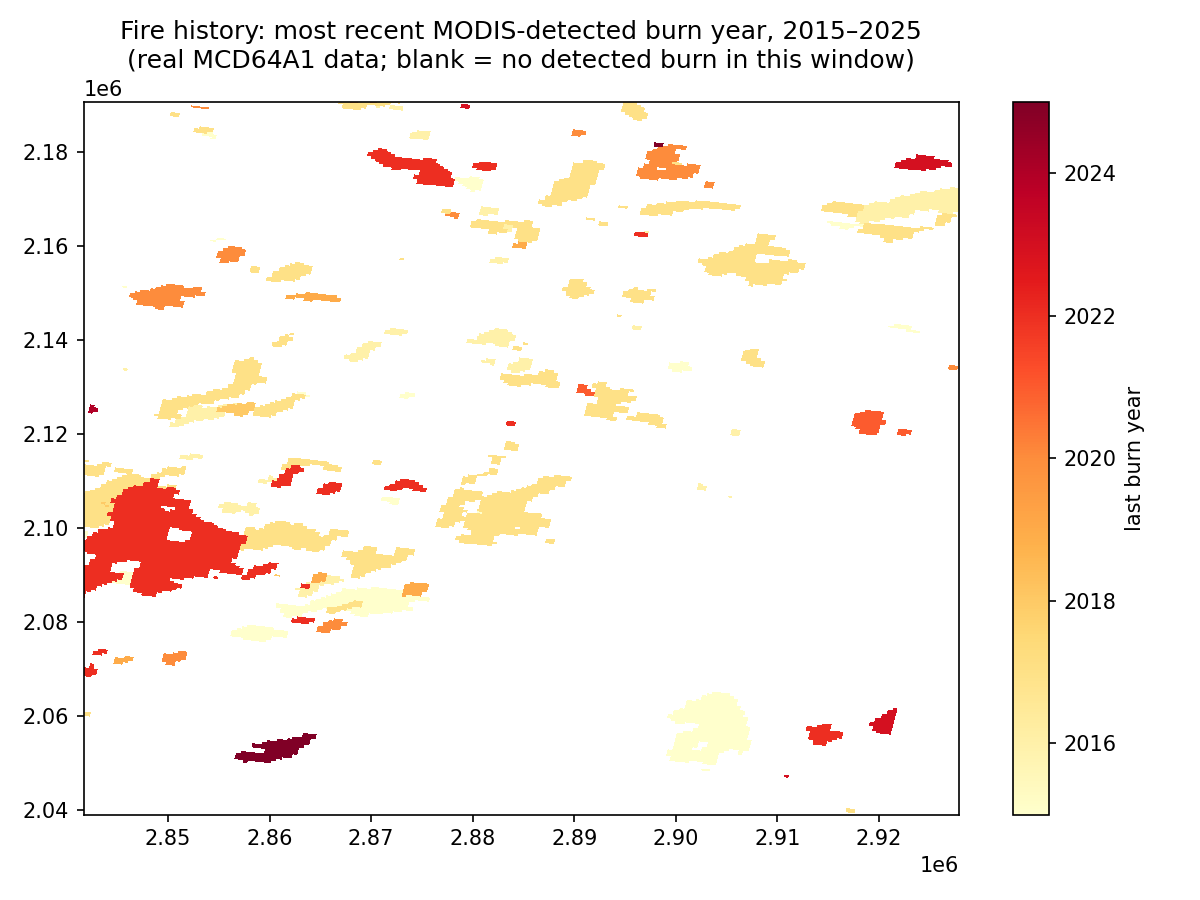

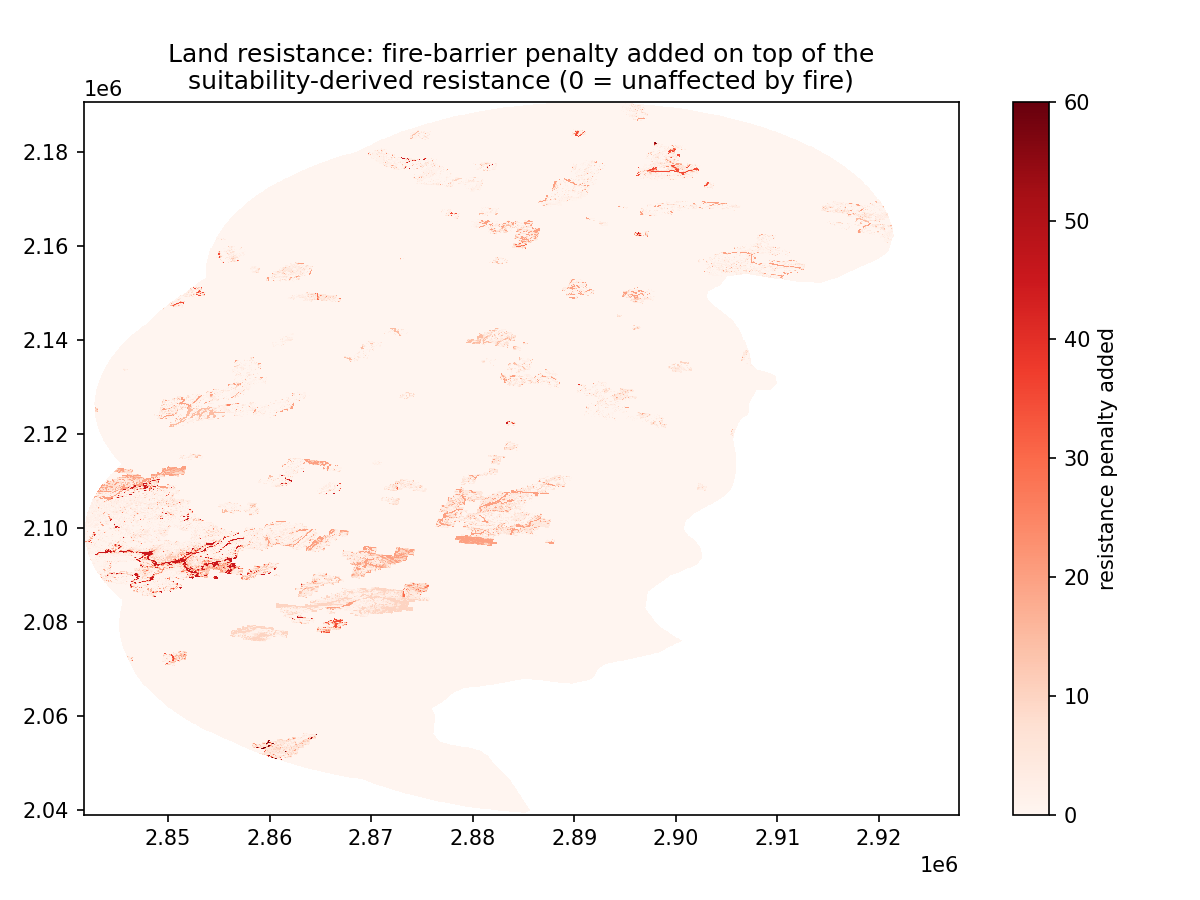

In [11]:
display(Image(str(config.OUTPUT_MAPS / "09_fire_history.png")))
display(Image(str(config.OUTPUT_MAPS / "10_fire_resistance_effect.png")))

## Multi-species combined connectivity

Same species-count-weighted averaging as v1 (Land 3, Water 4, Air 3 species). Because the fire penalty is already baked into `land_normalized_current.tif` by this point, its effect propagates through into both the mean and max multispecies rasters below — a genuinely fire-aware combined connectivity output, not a separate overlay.

multispecies_mean_connectivity: range [0.676, 2.788], mean 1.005
  wrote /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/output/rasters/multispecies_mean_connectivity.tif
multispecies_max_connectivity: range [0.868, 4.497], mean 1.219
  wrote /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/output/rasters/multispecies_max_connectivity.tif
  wrote 06_multispecies_mean.png


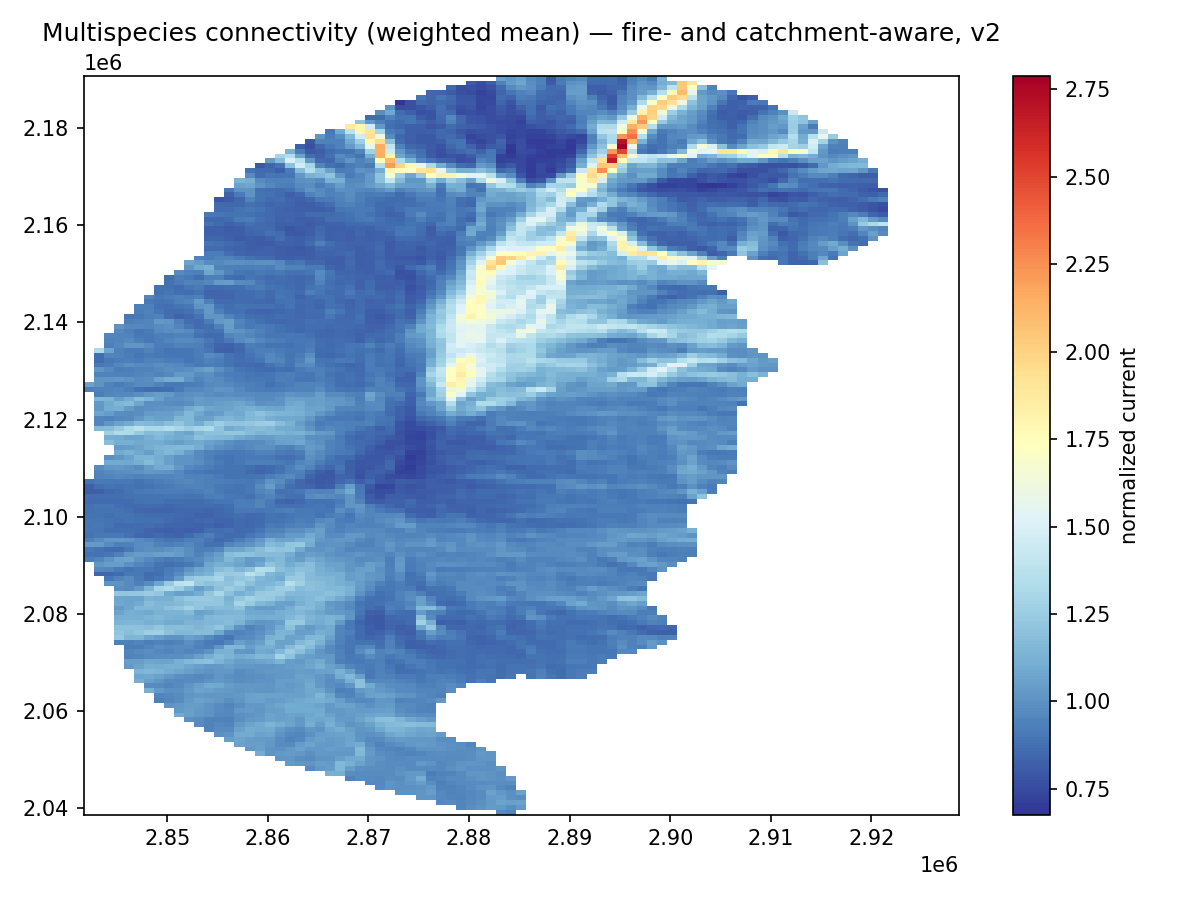

In [12]:
%run combine_connectivity.py
generate_maps._plot_raster(config.OUTPUT_RASTERS / "multispecies_mean_connectivity.tif",
                            "Multispecies connectivity (weighted mean) — fire- and catchment-aware, v2", "RdYlBu_r",
                            out_name="06_multispecies_mean.png", cbar_label="normalized current")
display(Image(str(config.OUTPUT_MAPS / "06_multispecies_mean.png")))

## Roads and waterways: barrier vs. access

Unchanged from v1 — roads and waterways classified into conservation priority / compatible access / conflict, against the same visitor-site list. The Foz Côa cofferdam remains the clearest case where conservation and heritage-tourism readings align rather than trade off.

*Simplification note, unchanged*: the waterway barrier-severity layer still reuses the Water group's resistance surface rather than a separate dam/weir point layer.

Road trade-off maps written
Waterway trade-off maps written


  wrote 07_road_tradeoff.png


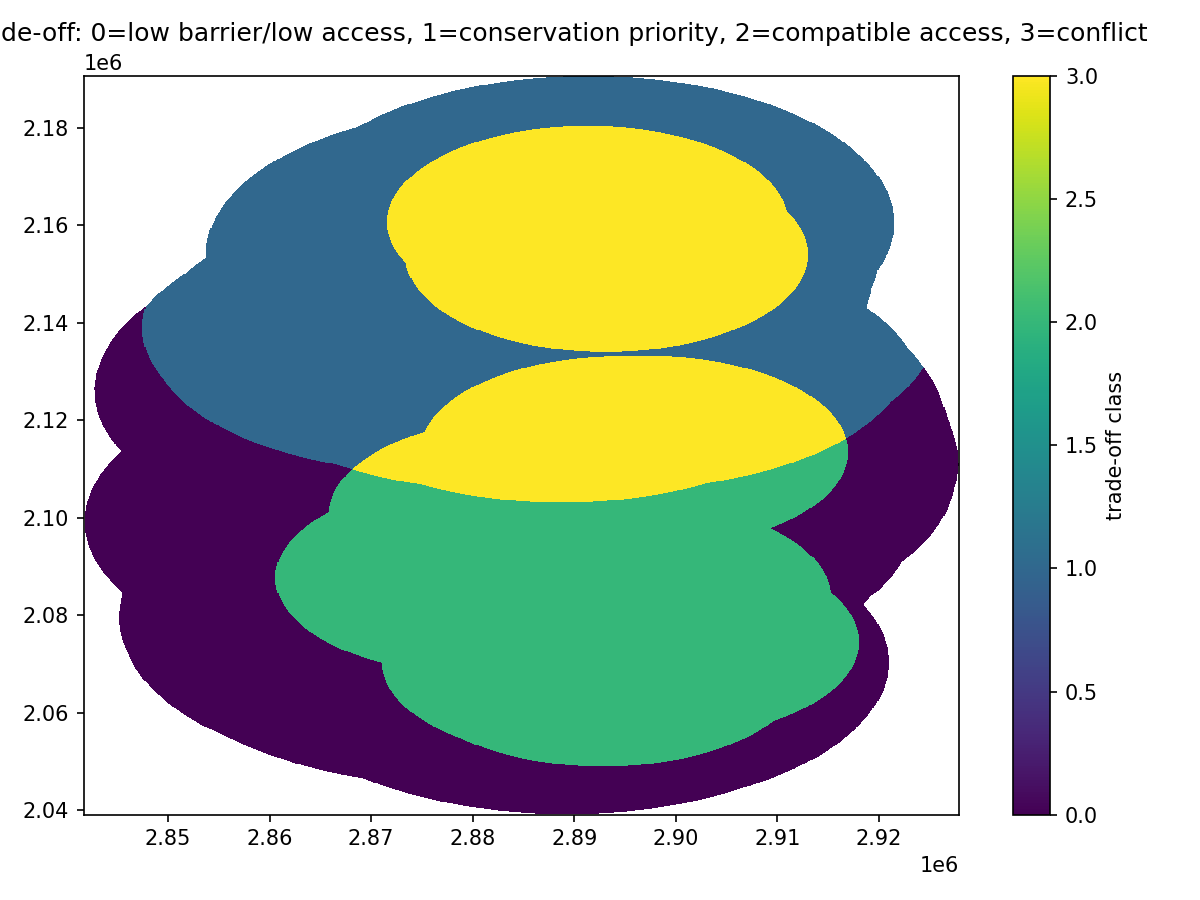

In [13]:
%run build_tradeoff_maps.py
generate_maps._plot_raster(config.OUTPUT_RASTERS / "road_tradeoff_class.tif",
    "Road trade-off: 0=low barrier/low access, 1=conservation priority, 2=compatible access, 3=conflict",
    "viridis", out_name="07_road_tradeoff.png", cbar_label="trade-off class")
display(Image(str(config.OUTPUT_MAPS / "07_road_tradeoff.png")))

  wrote 08_waterway_tradeoff.png


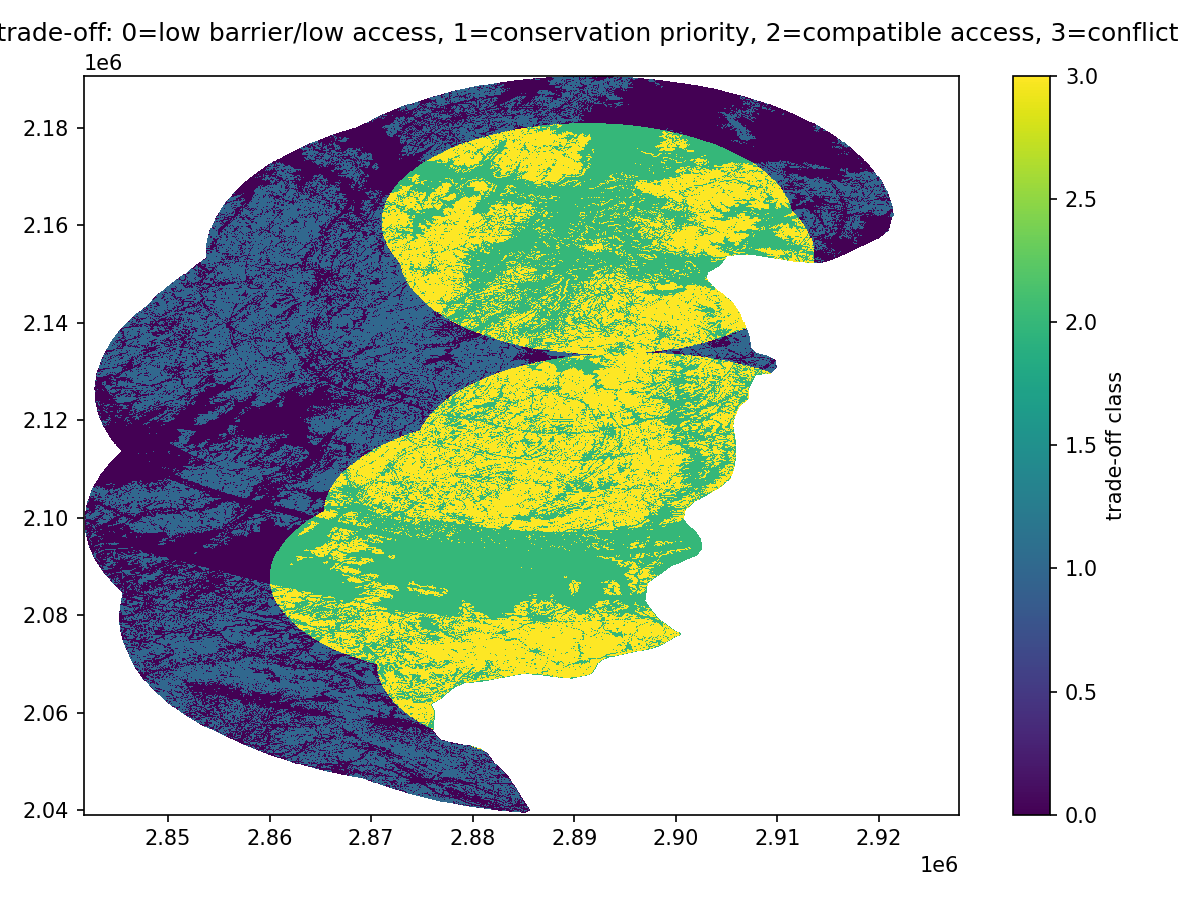

In [14]:
generate_maps._plot_raster(config.OUTPUT_RASTERS / "waterway_tradeoff_class.tif",
    "Waterway trade-off: 0=low barrier/low access, 1=conservation priority, 2=compatible access, 3=conflict",
    "viridis", out_name="08_waterway_tradeoff.png", cbar_label="trade-off class")
display(Image(str(config.OUTPUT_MAPS / "08_waterway_tradeoff.png")))

## Land tenure context

Unchanged from v1 — Faia Brava private reserve boundary (OSM/WDPA) and ICNF's hunting-zone cadastre (ZCM/ZCA/ZCT via WFS), re-clipped to the v2 extended study area (337 hunting zones now returned, up from the smaller v1 extent's count). Still deliberately not folded into the resistance surfaces — descriptive context, not a modelled barrier/asset, for the same reason as v1: this project has no first-hand knowledge of any specific estate's actual management.

Private reserves: 1 (Faia Brava)


Hunting zones (ICNF zonas de caça): 337
fig_ord
ZCA    194
ZCM    108
ZCT     35
Wrote /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/data/processed/land_tenure.gpkg


  wrote 02_land_tenure.png


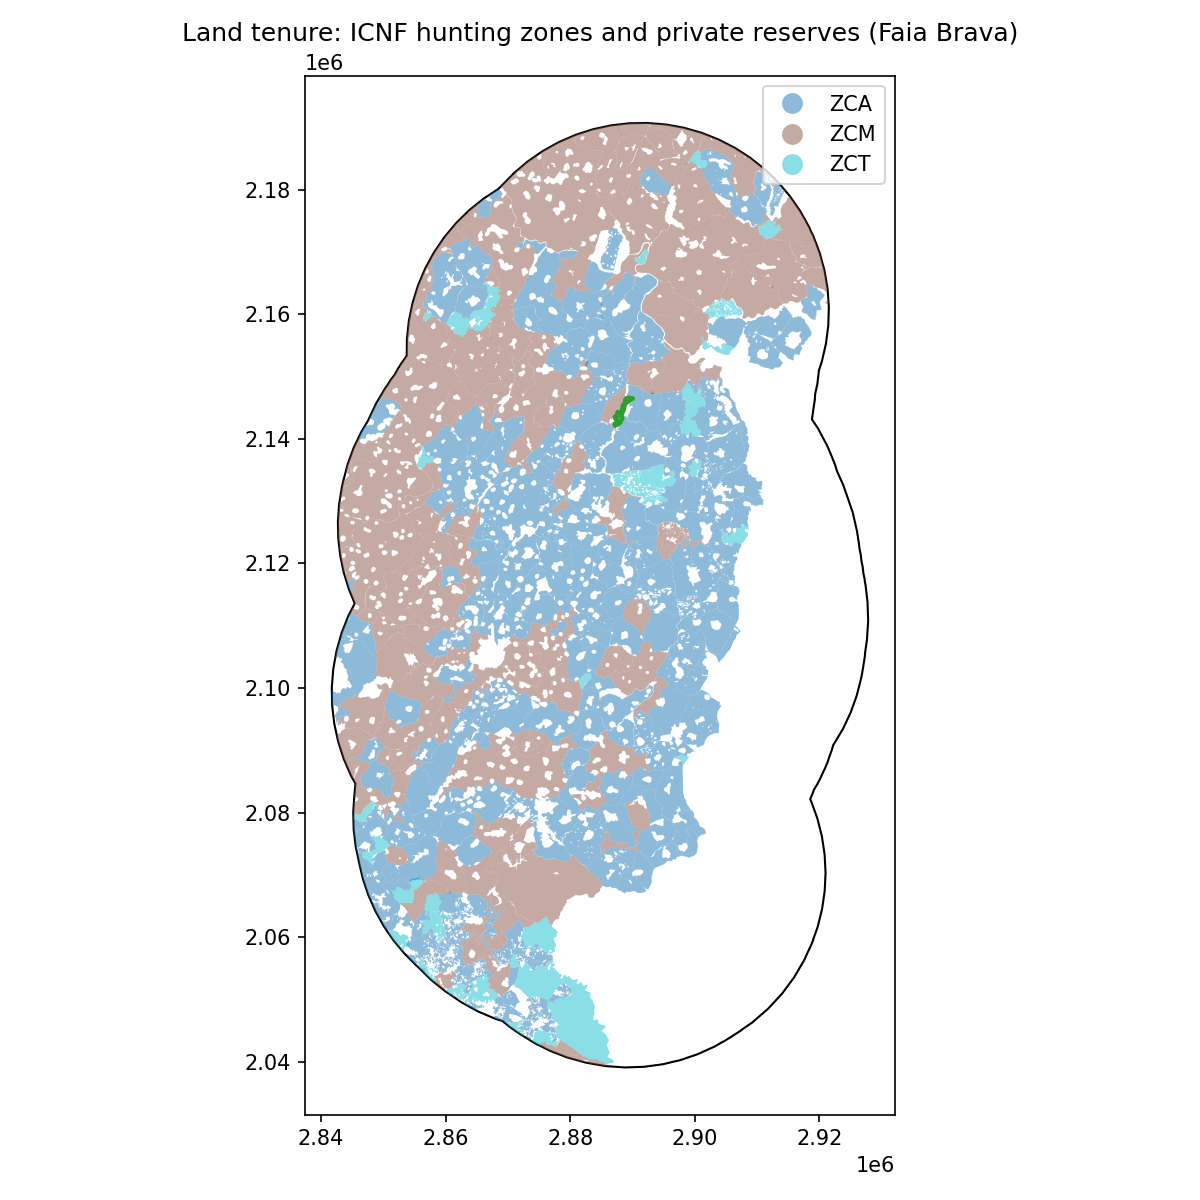

In [15]:
%run acquire_reserves_and_hunting_zones.py
generate_maps.map_02_land_tenure()
display(Image(str(config.OUTPUT_MAPS / "02_land_tenure.png")))

In [16]:
%run acquire_tourism_sites.py

not_yet_visited: 3 sites
potential_ecotourism_sites: 6 sites
                                                  name  connectivity_value          corridor_note
                               Pontao Manuel Jose weir            0.952885  low-connectivity zone
Nascente do Rio Coa / Estacao de Biodiversidade, Foios            0.927866  low-connectivity zone
                          Penascosa rock art reception            1.212922 high-connectivity zone
                       Praia Fluvial de Vale das Eguas            0.944324  low-connectivity zone
                       Praia Fluvial de Rapoula do Coa            0.968965 high-connectivity zone
                              Lageosa (Sorraia horses)            1.031936 high-connectivity zone
Wrote /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/data/processed/tourism_sites.gpkg


## Eco-tourism and safe-and-just

Unchanged from v1 in substance — the human-wildlife-conflict, eco-tourism-siting, and "what this notebook does not claim" discussion all carry forward as written there. One v2-relevant addition worth naming: fire-affected land (10.07% of the study area, mapped above) is itself a real land-management/visitor-safety consideration for any site near recently-burned ground, not modelled quantitatively here — a candidate for a future pass, not a finding of this one.

### Rewilding Portugal's own flagship species, cross-referenced against this notebook's 10 focal species

`references/ecological-information/data/annual_review_2025_species.csv` (compiled from the 2025 annual review in a prior session) names seven flagship species as present in the Greater Côa Valley: European beaver, Sorraia horse, Tauros, cinereous vulture, Egyptian vulture, red deer, and an unspecified GPS-tagged scavenging-bird group. Checked against this notebook's 10 GBIF-modelled species (`config.GROUPS`):

- **Already modelled here**: red deer (Land), Egyptian vulture (Air).
- **Named by Rewilding Portugal but not modelled in this connectivity analysis**: the European beaver (no GBIF/resistance layer in this project at all — a real gap, not silently patched over here), Sorraia horse and Tauros (semi-wild reintroduced grazers, not wild-dispersing species in the sense this framework models), cinereous vulture (a close relative of the two vulture species already in the Air group, but not itself included).

Stated as an explicit gap rather than expanding the species list without being asked — adding the beaver as a genuine 4th Water-group member (it has real GBIF-style presence data potential given the 2025 border-area sightings) would be a reasonable next step, not undertaken in this pass.

## Validation

Same checks as v1 — grid/CRS alignment across every output raster (now including the fire-augmented `land_resistance.tif`, confirmed to still share the same grid as every other output), and the road-proximity direction-of-effect check. Neither is a statistical validation; same caveats as v1's Method section.

In [17]:
%run validate_results.py

Grid alignment: OK (5 rasters checked)
Land connectivity near roads (<25th pct distance): mean 0.984
Land connectivity far from roads (>75th pct distance): mean 1.008
  Direction as expected: lower connectivity near roads.
Survey123 visited sites available for spot-check: 12 (barrier-type/permeability fields are free text in this prototype export - see acquire_field_observations.py docstring - so this is a manual read, not automated).


## Limpopo, South Africa — strategic lessons for expanding the Greater Côa Valley initiative

Rewilding Portugal's own material repeatedly reaches for South African/East African imagery to describe the Côa Valley (the savanna-like structure noted in this project's own field notes; roe deer "repopulating valleys and clearings" language echoing African rewilding narratives). This section takes that comparison seriously and literally: how do savanna-landscape rewilding, land restoration, and ecotourism initiatives in Limpopo province, South Africa, actually work — legally, financially, and operationally — and what, concretely, could the Côa Valley initiative adapt from them to expand its own reach? Built from real South African government/policy/academic sources (cited by URL throughout), not first-hand Limpopo fieldwork — unlike the Côa Valley sections above, which lean on Linda's own field notes and Survey123 records. These are strategic *options* worth Rewilding Portugal evaluating, not decisions this notebook makes on the organisation's behalf.

### Connectivity & rewilding method: fence removal vs. circuit theory

The [Associated Private Nature Reserves](https://en.wikipedia.org/wiki/Associated_Private_Nature_Reserves) (APNR — Balule, Kapama, Klaserie, Timbavati, Thornybush, Umbabat; 1,800km²/180,000ha) and the wider [Great Limpopo Transfrontier Conservation Area](https://www.peaceparks.org/tfcas/great-limpopo/) (GLTFCA — South Africa/Mozambique/Zimbabwe, ~10,000,000ha) scaled up almost entirely through **physical fence removal between neighbouring landowners**, not land purchase: the Kruger/APNR boundary fence came down in June 1993, and at Thornybush alone, dropping fences along the reserve's eastern side in 2017 reconnected more than 140km² with adjacent reserves and Kruger, with the elephant count surging from 55 to 770 between 2017 and 2019 ([NASA Earth Observatory](https://science.nasa.gov/earth/earth-observatory/rewilding-south-africas-greater-kruger)). Worth stating plainly rather than presenting fence removal as an unambiguous win: that same NASA source notes the resulting high elephant density drove substantial woody-vegetation loss (browsing, bark-stripping, uprooting) — a real trade-off of fast connectivity gains, not a free lunch.

This is a fundamentally different (and, per-hectare, far cheaper) scaling mechanism than Rewilding Portugal's current model of direct land purchase — 997ha bought to date toward a 5,000ha-by-2030 target, per the [Endangered Landscapes & Seascapes Programme project page](https://www.endangeredlandscapes.org/project/greater-coa-valley/) (`references/ecological-information/endangeredlandscapes-org-project-greater-coa-valley.pdf`, already in this repo).

**Implication for expansion**: land-tenure coordination and fencing/access agreements with neighbouring private landowners along the traced tributary catchment (map in the Study Area section above) could be a lower-cost connectivity-scaling lever than land acquisition alone — with the Thornybush vegetation-loss caveat above as a reason to pair any such agreement with active grazer/browser-density management, not treat "remove the barrier" as the whole plan. Separately: GLTFCA's cross-border, three-country model is a concrete long-horizon reference for a possible Portugal–Spain transfrontier extension, since the Côa/Douro system already crosses into Spain (Arribes del Duero, named in this notebook's own Water section since v1).

### Land restoration as a legal obligation vs. a grant-funded initiative

South Africa's Mineral and Petroleum Resources Development Act (MPRDA, 2002) originally required mining companies to post financial provision (cash deposits, bank guarantees, or trust funds) against future rehabilitation costs; that requirement has since been repealed and replaced by **[NEMA Section 24P](https://cer.org.za/news/what-you-should-know-about-proposed-new-rules-for-financial-provision-for-mining-rehabilitation)**, jointly administered by the Department of Mineral Resources and Energy (DMRE, the competent implementing authority) and the Department of Forestry, Fisheries and the Environment (DFFE, the legislative authority) — see also [Mining Weekly's summary of the legal requirements for mine closure](https://www.miningweekly.com/article/legal-requirements-for-mine-closure-in-south-africa-2023-07-06). This makes rehabilitation a **legally bonded financial obligation on the party causing the degradation**, not a grant-dependent voluntary undertaking. The concrete Limpopo case: [Palabora Mining Company](https://www.miningweekly.com/article/mining-beyond-profits-shows-commitment-to-communities-environment-and-wildlife-conservation-2023-12-15) (copper, directly adjacent to Kruger National Park) runs tailings backfill, progressive native revegetation, and a Biodiversity Action Plan for its Kruger-adjacent Big Five/wildlife coexistence, under ISO 14001 certification.

There's also a direct methodological echo worth naming: both this notebook's fire-barrier work above and South Africa's mine-rehabilitation regime build a resistance/obligation model around an **actively degrading force** — wildfire here, extraction there — just a different forcing mechanism and a very different institutional backing (a real MODIS-derived recency penalty on a voluntarily-funded resistance surface, vs. a legally bonded closure obligation).

**Implication for expansion**: a legally-mandated financial-provisioning mechanism — for wildfire-adjacent land degradation, or for any future extractive/development pressure near the Côa Valley — is a genuine EU/Portuguese policy-advocacy angle Rewilding Portugal could pursue for funding resilience beyond Endangered Landscapes-style grant dependency. Stated as a real option worth raising, not as something already planned or in motion.

### Water governance: a binding ecological Reserve vs. a stalled protocol

South Africa's **[National Water Act, 1998 (Act 36 of 1998)](https://faolex.fao.org/docs/pdf/saf123836.pdf)** created "the Reserve" — a legally binding minimum water allocation covering both basic human needs and ecosystem health, which takes precedence over water-use rights and was explicitly designed to correct apartheid-era water inequity favouring large-scale white farmers over small-scale Black farmers. That's a meaningfully stronger legal instrument than anything currently governing the Côa's own water: the EU Water Framework Directive water-bodies layer already in this project's pipeline (`data/processed/hydrology_and_protected_areas.gpkg`) is descriptive, not a binding minimum-flow guarantee, and the protocol to remove the Foz Côa cofferdam — signed by Rewilding Portugal, the Portuguese Environment Agency, and the Côa Parque Foundation back in 2023 — is still "awaiting approval" per the 2025 annual review, three years on.

**Implication for expansion**: the National Water Act's Reserve is a citable international precedent for a binding minimum-ecological-flow allocation — useful, real leverage in advocacy for finally moving the stalled cofferdam-removal protocol forward, not just a passive parallel.

### Equity, "just," and tourism transformation

Two South African threads connect directly to this notebook's own "safe and just" framing (see the footnote added to that section above): the **[Reconstruction and Development Programme (RDP, 1994)](https://en.wikipedia.org/wiki/Reconstruction_and_Development_Programme)**, the ANC's founding post-apartheid policy framework (land restitution targeting 30% of agricultural land, basic-needs provision), and **Cole, Bailey & New's (2017)** direct application of Raworth's doughnut model at provincial level across South Africa, Limpopo included. On the tourism side specifically, the Department of Tourism's **[National Tourism Sector Strategy 2016–2026](https://www.tourism.gov.za/AboutNDT/Publications/National%20Tourism%20Sector%20Strategy%20Executive%20Summary.pdf)** and **[2018 Transformation Strategy for the Tourism Sector](https://www.tourism.gov.za/CurrentProjects/Documents/Transformation%20Strategy%20for%20the%20Tourism%20sector.pdf)** explicitly target redressing historical racial exclusion from tourism ownership and participation, with community-based tourism as a stated national priority.

The Wild Côa Network (64 members per the 2025 annual review) already shares the goal of rural economic diversification and community benefit-sharing — but its current framing is rural-development-oriented, not equity/transformation-oriented in the explicit sense South Africa's strategy names. That's a genuine difference worth stating plainly, not smoothing into a false equivalence: Portugal's rural depopulation and South Africa's post-apartheid ownership exclusion are different problems, even where the tourism-policy tools (community-based models, explicit participation targets) look similar on paper.

**Implication for expansion**: as the Wild Côa Network grows, an explicit local-ownership/benefit-sharing target — not just general "rural development" language — is a concrete, adoptable lesson from South Africa's transformation-strategy approach, and it strengthens positioning for EU funding calls that specifically value inclusive-growth framing.

### Scale reality check

GLTFCA's ~10,000,000ha is roughly **10x** the Côa Valley's catchment-extended study area from this notebook (10,230km² = 1,023,000ha, see Study Area section above). Stated plainly so every implication above reads as "a mechanism worth adapting at the Côa Valley's own scale," not "a comparable scale already reached."

### Summary comparison

| Dimension | Greater Côa Valley (this notebook) | Limpopo, South Africa |
|---|---|---|
| Legal/regulatory driver | EU Water Framework Directive (descriptive), stalled cofferdam-removal protocol | National Water Act's binding ecological Reserve; NEMA §24P mandatory mine-rehabilitation bonding |
| Funding model | Endangered Landscapes Programme grant + direct land purchase (997ha to date) | Legally bonded financial provisioning (mining); park/reserve revenue + donor funding (APNR/GLTFCA) |
| Connectivity-scaling mechanism | Circuit-theory resistance modelling (this notebook); land purchase | Physical fence removal between neighbouring landowners (APNR 1993, Thornybush 2017) |
| Degradation-barrier type modelled | Wildfire (real MODIS burn history, this notebook's v2 addition) | Historical fencing/land fragmentation; mining-site disturbance (Palabora) |
| Equity/"just" framing | Rural economic diversification (Wild Côa Network) | Explicit racial-equity transformation target (Dept. of Tourism); RDP land restitution |
| Scale | 10,230km² (catchment-extended study area) | ~180,000ha (APNR) to ~10,000,000ha (GLTFCA, cross-border) |

## Handoff

Same handoff as v1: `output/rasters/` and `output/maps/` are the finished products for the StoryMap's closing chapter; `qgis/coa_eco_connectivity_ecotourism.qgz` carries every layer (now including a new "Fire history" group, and the traced tributary network in "Base context") into an interactive form.

**Known limitations, v1's list carried forward plus what's new in v2:**
- One suitability model and one parameter set per group, not Prima et al.'s full ensemble/uncertainty sweep.
- No held-out validation split; no movement-tracking data to check against.
- Air-group suitability likely reflects recording density more than true habitat preference.
- Waterway barrier severity reuses the Water resistance surface rather than a dedicated dam/weir layer.
- Land-tenure layer is descriptive context, not a validated barrier/asset classification.
- "Just" is checked against reachability and corridor impact only — no equity/accessibility data exists in this project.
- **New — catchment tracing is topology-based, not a true DEM watershed**: HydroRIVERS' generalised (`_100`) network was traced via `NEXT_DOWN` topology, not delineated from the DEM's actual flow accumulation. It's a real river network, not a fabricated one, but it isn't a HydroBASINS-style watershed polygon either.
- **New — fire data stops at ~1 July 2025**: MODIS MCD64A1 via Planetary Computer hasn't ingested later 2025/2026 fires yet (checked globally). The annual review's own 2025 fires and the 2026 Almeida-area fire are narrative-only in this notebook, not in the fire raster.
- **New — fire penalty is land-group-only**: post-fire erosion/sediment effects on the Water group are a real, plausible interaction, not modelled here.
- **New — Rewilding Portugal's 318,000ha project boundary has no polygon anywhere in either repo**: the catchment-extended study area (10,230 km², 3.2x larger) is used as a documented stand-in, not a precise match.
- **New — the beaver, Sorraia horse, Tauros, and cinereous vulture** are named as present by Rewilding Portugal's own annual review but aren't modelled as focal species in this connectivity analysis.
- **New in v3 — the Limpopo comparison is policy/literature-based, not fieldwork-based**: built from South African government, legal, and academic sources gathered this session, not first-hand site visits or data, unlike the Côa Valley material above. Its "implication for expansion" statements are options for Rewilding Portugal to evaluate, not decisions this notebook makes on the organisation's behalf.